# Punto 2: Comparación de longitud y estados con BFS y DFS

In [21]:
from collections import deque

from matplotlib import pyplot as plt

In [22]:
# Matriz que representa el laberinto 10x10.
laberinto = [
    [0, 1, 1, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 1, 1],
    [0, 1, 0, 1, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 1],
    [0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0]
]

# Coordenada inicial.
INICIO = (0, 0)

# Coordenada que queremos alcanzar.
OBJETIVO = (9, 9)

# Cada tupla indica cuánto cambia (fila, columna).
# ( 1, 0) -> abajo
# (-1, 0) -> arriba
# ( 0, 1) -> derecha
# ( 0,-1) -> izquierda
#
# El orden importa especialmente en DFS.

MOVIMIENTOS = [
    (0, -1),  # izquierda
    (0, 1),   # derecha
    (-1, 0),  # arriba
    (1, 0),   # abajo
]

In [23]:
def sucesores_laberinto(laberinto, posicion):
    # Número de filas de la matriz.
    filas = len(laberinto)

    # Número de columnas de la matriz.
    columnas = len(laberinto[0])

    # Desempaquetamos la posición actual.
    f, c = posicion

    # Aquí guardaremos únicamente movimientos válidos.
    sucesores = []

    # Probamos cada desplazamiento definido en MOVIMIENTOS.
    for df, dc in MOVIMIENTOS:
        # Calculamos la posible nueva fila y columna.
        nf, nc = f + df, c + dc

        # La posición es válida solamente si:
        # 1. La fila queda dentro del laberinto.
        # 2. La columna queda dentro del laberinto.
        # 3. La celda contiene 0, es decir, no es una pared.
        if (
            0 <= nf < filas
            and 0 <= nc < columnas
            and laberinto[nf][nc] == 0
        ):
            sucesores.append((nf, nc))

    # Devolvemos todas las posiciones alcanzables desde la actual.
    return sucesores

# BFS

In [24]:
def bfs_camino_laberinto(laberinto, inicio, objetivo):
    # Si el inicio está sobre una pared, el problema no es válido.
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None

    # Si el objetivo está sobre una pared, tampoco puede existir solución.
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    # Cada elemento de la cola contiene:
    # (posición_actual, camino_usado_para_llegar_hasta_ella)
    cola = deque([(inicio, [inicio])])

    # Evita volver a insertar posiciones ya descubiertas.
    visitados = {inicio}

    # Orden en que BFS examina cada estado, al sacarlo de la cola.
    orden = []

    # Continuamos mientras queden posiciones pendientes.
    while cola:
        # BFS saca el elemento más antiguo.
        posicion, camino = cola.popleft()
        orden.append(posicion)

        # Si la posición actual es la meta, terminamos.
        if posicion == objetivo:
            return {
                "camino": camino,

                # En el notebook original se llama "explorados".
                # En realidad corresponde a la cantidad de estados descubiertos.
                "explorados": len(visitados),
                "visitados": orden,
            }

        # Generamos todas las posiciones válidas vecinas.
        for nuevo in sucesores_laberinto(laberinto, posicion):
            # Solo procesamos posiciones nuevas.
            if nuevo not in visitados:
                visitados.add(nuevo)

                # Guardamos también el camino acumulado hasta el nuevo estado.
                cola.append((nuevo, camino + [nuevo]))

    # Si se vacía la cola sin encontrar el objetivo, no existe camino.
    return None


resultado_bfs = bfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_bfs

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (5, 0),
  (6, 0),
  (7, 0),
  (7, 1),
  (7, 2),
  (8, 2),
  (8, 3),
  (8, 4),
  (8, 5),
  (8, 6),
  (8, 7),
  (8, 8),
  (8, 9),
  (9, 9)],
 'explorados': 47,
 'visitados': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (4, 1),
  (5, 0),
  (4, 2),
  (6, 0),
  (4, 3),
  (3, 2),
  (7, 0),
  (4, 4),
  (2, 2),
  (7, 1),
  (8, 0),
  (3, 4),
  (1, 2),
  (7, 2),
  (9, 0),
  (2, 4),
  (6, 2),
  (8, 2),
  (1, 4),
  (6, 3),
  (8, 3),
  (0, 4),
  (6, 4),
  (8, 4),
  (0, 3),
  (0, 5),
  (6, 5),
  (8, 5),
  (0, 6),
  (6, 6),
  (8, 6),
  (1, 6),
  (5, 6),
  (8, 7),
  (2, 6),
  (4, 6),
  (8, 8),
  (3, 6),
  (8, 9),
  (3, 7),
  (9, 9)]}

# DFS

In [25]:
def dfs_camino_laberinto(laberinto, inicio, objetivo):
    # Validamos que inicio y objetivo no sean paredes.
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    # Cada elemento contiene:
    # (posición_actual, camino_usado_para_llegar_hasta_ella)
    #
    # Aquí usamos una lista como pila.
    pila = [(inicio, [inicio])]

    # Evita visitar dos veces el mismo estado.
    visitados = {inicio}

    # Orden en que DFS examina cada estado, al sacarlo de la pila.
    orden = []

    # Continuamos mientras existan estados pendientes.
    while pila:
        # DFS saca el último elemento agregado.
        posicion, camino = pila.pop()
        orden.append(posicion)

        # Si llegamos al objetivo, devolvemos el resultado.
        if posicion == objetivo:
            return {
                "camino": camino,
                "explorados": len(visitados),
                "visitados": orden,
            }

        # Obtenemos los vecinos válidos de la posición actual.
        for nuevo in sucesores_laberinto(laberinto, posicion):
            # Agregamos únicamente estados que todavía no hayan sido descubiertos.
            if nuevo not in visitados:
                visitados.add(nuevo)

                # Al ser una pila, el último sucesor insertado será el primero
                # que DFS examine en la siguiente iteración.
                pila.append((nuevo, camino + [nuevo]))

    # Si se vacía la pila sin encontrar la meta, no existe solución.
    return None


resultado_dfs = dfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_dfs

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (5, 0),
  (6, 0),
  (7, 0),
  (7, 1),
  (7, 2),
  (8, 2),
  (8, 3),
  (8, 4),
  (8, 5),
  (8, 6),
  (8, 7),
  (8, 8),
  (8, 9),
  (9, 9)],
 'explorados': 23,
 'visitados': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (5, 0),
  (6, 0),
  (7, 0),
  (8, 0),
  (9, 0),
  (7, 1),
  (7, 2),
  (8, 2),
  (8, 3),
  (8, 4),
  (8, 5),
  (8, 6),
  (8, 7),
  (8, 8),
  (8, 9),
  (9, 9)]}

# Comparación

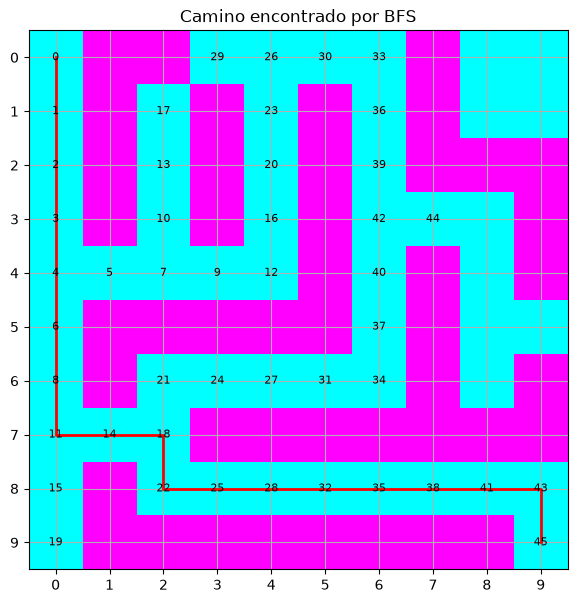

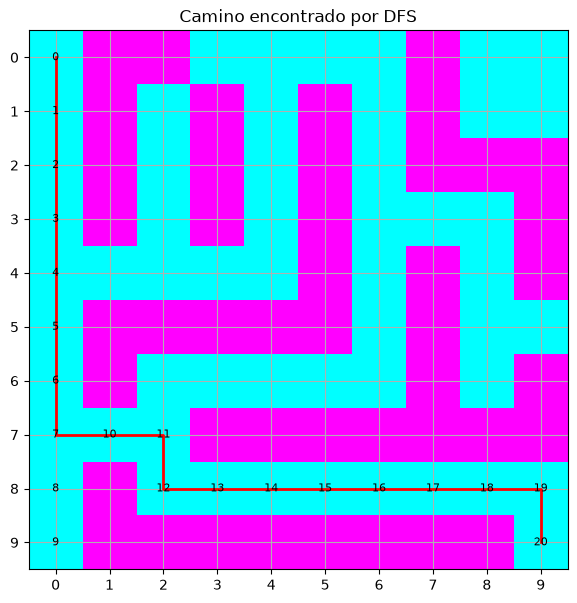

In [26]:
def mostrar_laberinto(
    laberinto,
    camino=None,
    titulo="Laberinto",
    visitados=None,
):
    # Creamos la figura donde se dibujará la matriz.
    fig, ax = plt.subplots(figsize=(7, 7))

    # Mostramos los valores 0 y 1 como una imagen.
    ax.imshow(laberinto, cmap="cool")

    # Si existe un camino, separamos sus columnas (x) y filas (y)
    # para poder dibujar una línea que una las posiciones.
    if camino:
        xs = [c for f, c in camino]
        ys = [f for f, c in camino]
        ax.plot(xs, ys, c="red", linewidth=2)

    # El número es el paso en que el algoritmo examinó esa celda.
    if visitados:
        for paso, (f, c) in enumerate(visitados):
            ax.text(
                c,
                f,
                str(paso),
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                zorder=3,
            )

    # Ajustamos los ejes al tamaño real del laberinto.
    ax.set_xticks(range(len(laberinto[0])))
    ax.set_yticks(range(len(laberinto)))

    ax.set_title(titulo)
    ax.grid(True)
    plt.show()


mostrar_laberinto(
    laberinto,
    resultado_bfs["camino"],
    "Camino encontrado por BFS",
    resultado_bfs["visitados"],
)

mostrar_laberinto(
    laberinto,
    resultado_dfs["camino"],
    "Camino encontrado por DFS",
    resultado_dfs["visitados"],
)

In [27]:
# La longitud del camino se calcula restando 1 porque:
# número de posiciones = número de movimientos + 1.
comparacion = {
    "BFS": {
        "longitud_camino": len(resultado_bfs["camino"]) - 1,
        "explorados": resultado_bfs["explorados"],
    },
    "DFS": {
        "longitud_camino": len(resultado_dfs["camino"]) - 1,
        "explorados": resultado_dfs["explorados"],
    },
}

comparacion

{'BFS': {'longitud_camino': 18, 'explorados': 47},
 'DFS': {'longitud_camino': 18, 'explorados': 23}}